# Gradient Descent with Momentum

We use a conservative step-size in 2D trajectory plots to avoid overshoot.


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython import get_ipython
ip = get_ipython()
if ip is not None:
    ip.run_line_magic("matplotlib", "inline")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
rng = np.random.default_rng(0)
OUT = Path(".")

A = np.array([[10., 2.], [2., 1.5]])
f = lambda x: 0.5 * x @ A @ x
g = lambda x: A @ x
x0 = np.array([1.8, -1.3])
eta = 0.06   # smaller step as requested
beta = 0.82
steps = 120


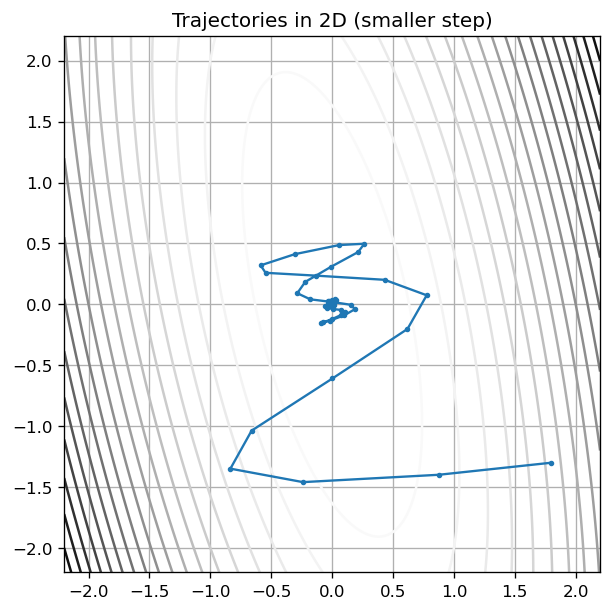

In [2]:
x = x0.copy(); v = np.zeros(2)
traj = [x.copy()]
for _ in range(steps):
    v = beta*v + g(x)
    x = x - eta*v
    traj.append(x.copy())
traj = np.array(traj)

xx = np.linspace(-2.2, 2.2, 220)
yy = np.linspace(-2.2, 2.2, 220)
XX, YY = np.meshgrid(xx, yy)
FF = 0.5*(A[0,0]*XX**2 + 2*A[0,1]*XX*YY + A[1,1]*YY**2)
fig, ax = plt.subplots(figsize=(6.2, 5.8))
ax.contour(XX, YY, FF, levels=20, cmap='Greys')
ax.plot(traj[:,0], traj[:,1], 'o-', ms=2.3, lw=1.4, color='tab:blue')
ax.set_aspect('equal')
ax.set_title('Trajectories in 2D (smaller step)')
fig.savefig(OUT / "snippet.png", bbox_inches='tight')
plt.show()
